<a href="https://colab.research.google.com/github/ZeyadArafat/Autonomous-Vehicle-Perception-Module/blob/main/Supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf


In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 66s 0us/step


In [3]:
print(X_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [4]:
import numpy as np

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)
print("Number of classes:", len(np.unique(y_train)))


Training set: (50000, 32, 32, 3) (50000, 1)
Test set: (10000, 32, 32, 3) (10000, 1)
Number of classes: 10


C:\Users\DELL\AppData\Local\Temp\ipykernel_7724\3274145935.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xlabel(class_names[int(y_train[i])])


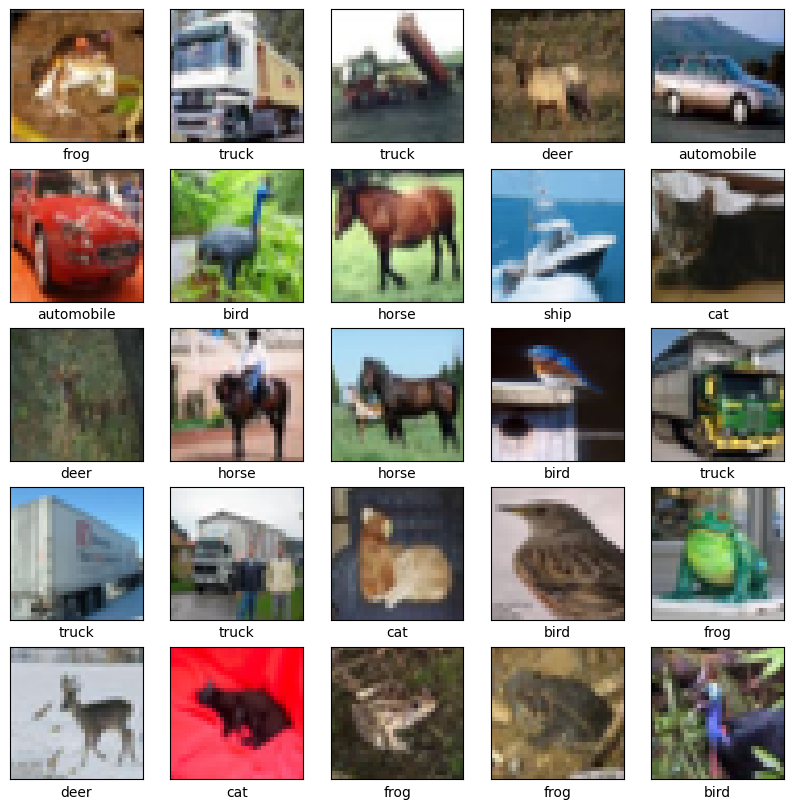

In [5]:
import matplotlib.pyplot as plt

# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[int(y_train[i])])
plt.show()


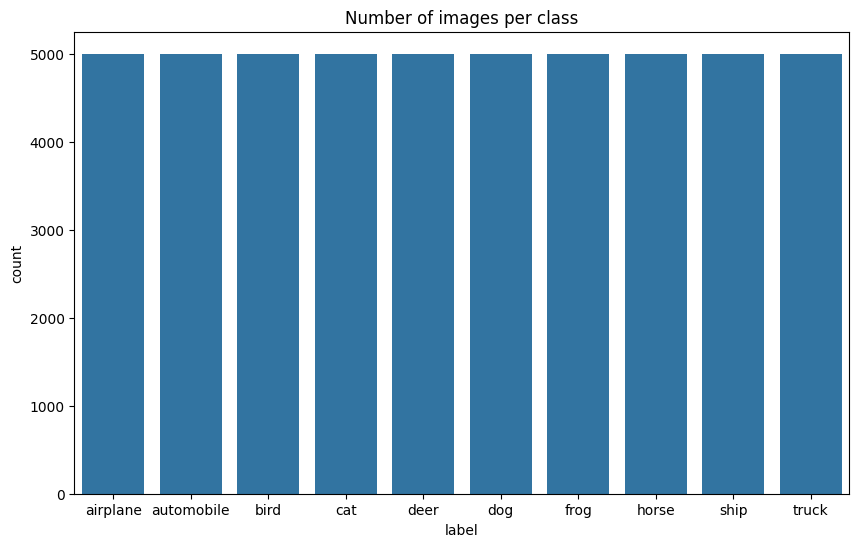

In [6]:
import seaborn as sns
import pandas as pd

y_train_flat = y_train.flatten()
df = pd.DataFrame({'label': y_train_flat})
plt.figure(figsize=(10,6))
sns.countplot(x='label', data=df)
plt.xticks(ticks=range(10), labels=class_names)
plt.title('Number of images per class')
plt.show()


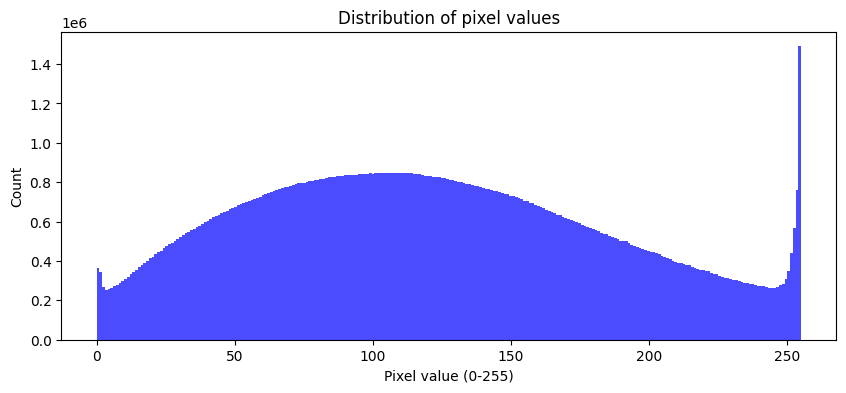

In [7]:
plt.figure(figsize=(10,4))
plt.hist(X_train.ravel(), bins=256, color='blue', alpha=0.7)
plt.title("Distribution of pixel values")
plt.xlabel("Pixel value (0-255)")
plt.ylabel("Count")
plt.show()


In [8]:
means = X_train.mean(axis=(0,1,2))
stds = X_train.std(axis=(0,1,2))
print("Channel means:", means)
print("Channel stds:", stds)


Channel means: [125.30691805 122.95039414 113.86538318]
Channel stds: [62.99321928 62.08870764 66.70489964]


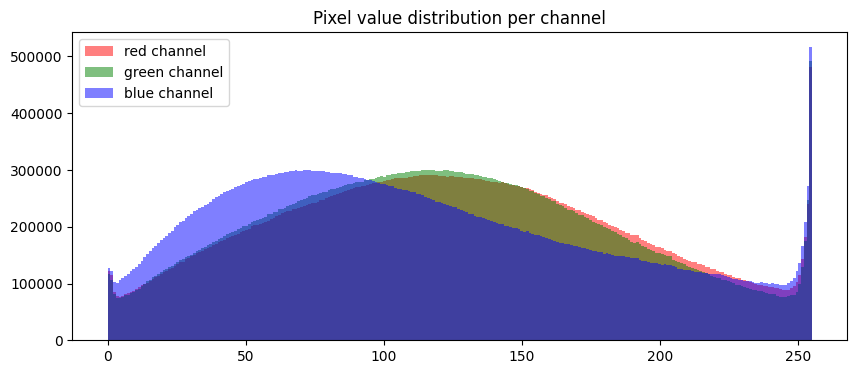

In [9]:
colors = ['red', 'green', 'blue']
plt.figure(figsize=(10,4))
for i, color in enumerate(colors):
    plt.hist(X_train[:,:,:,i].ravel(), bins=256, color=color, alpha=0.5, label=f'{color} channel')
plt.title("Pixel value distribution per channel")
plt.legend()
plt.show()


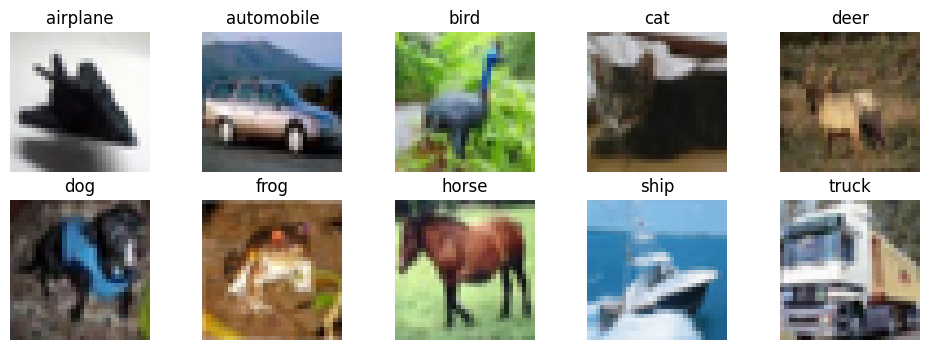

In [10]:
plt.figure(figsize=(12,4))
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[idx])
    plt.title(class_names[i])
    plt.axis('off')
plt.show()


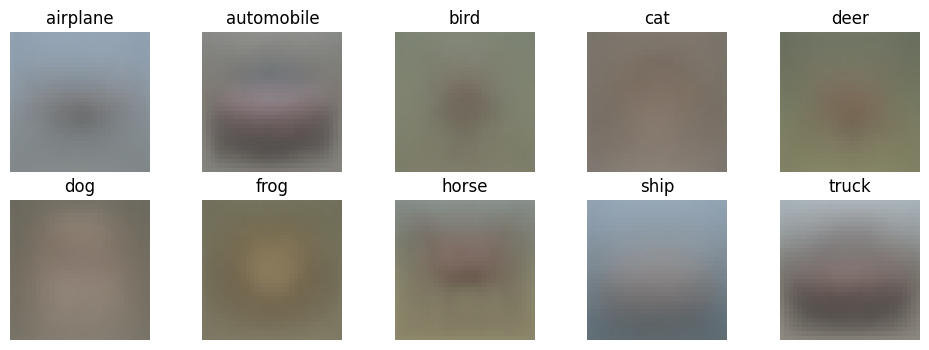

In [11]:
plt.figure(figsize=(12,4))
for i in range(10):
    idx = np.where(y_train == i)[0]
    mean_img = X_train[idx].mean(axis=0).astype(np.uint8)
    plt.subplot(2,5,i+1)
    plt.imshow(mean_img)
    plt.title(class_names[i])
    plt.axis('off')
plt.show()


In [12]:
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_train_df = pd.DataFrame(X_train_flattened)
X_train_df = X_train_df / 255.0
X_test_flattened = X_test.reshape(X_test.shape[0], -1)
X_test_df = pd.DataFrame(X_test_flattened)
X_test_df = X_test_df / 255.0
y_test_flat = y_test.flatten()
X_train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,3062,3063,3064,3065,3066,3067,3068,3069,3070,3071
0,0.231373,0.243137,0.247059,0.168627,0.180392,0.176471,0.196078,0.188235,0.168627,0.266667,...,0.407843,0.847059,0.721569,0.549020,0.592157,0.462745,0.329412,0.482353,0.360784,0.282353
1,0.603922,0.694118,0.733333,0.494118,0.537255,0.533333,0.411765,0.407843,0.372549,0.400000,...,0.533333,0.560784,0.521569,0.545098,0.560784,0.525490,0.556863,0.560784,0.521569,0.564706
2,1.000000,1.000000,1.000000,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,0.992157,...,0.309804,0.305882,0.333333,0.325490,0.309804,0.333333,0.325490,0.313725,0.337255,0.329412
3,0.109804,0.098039,0.039216,0.145098,0.133333,0.074510,0.149020,0.137255,0.078431,0.164706,...,0.149020,0.211765,0.184314,0.109804,0.247059,0.219608,0.145098,0.282353,0.254902,0.180392
4,0.666667,0.705882,0.776471,0.658824,0.698039,0.768627,0.694118,0.725490,0.796078,0.717647,...,0.305882,0.294118,0.309804,0.321569,0.278431,0.294118,0.305882,0.286275,0.301961,0.313725


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


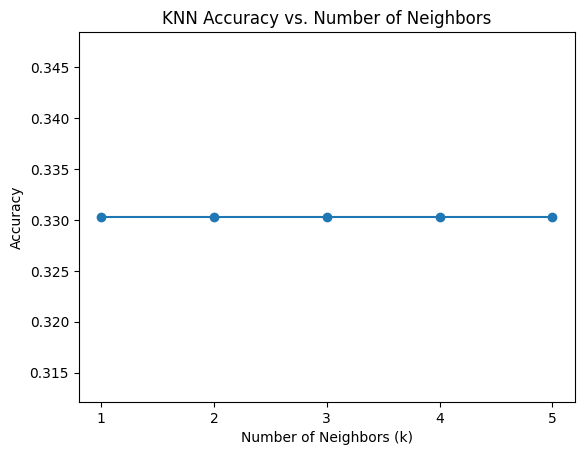

In [14]:

accuracies_kNN = []
for i in range(1, 6):
    KNN = KNeighborsClassifier(n_neighbors=3)
    KNN.fit(X_train_df, y_train_flat)
    y_pred_KNN = KNN.predict(X_test_df)
    accuracy_kNN = accuracy_score(y_test_flat, y_pred_KNN)
    accuracies_kNN.append(accuracy_kNN)
plt.plot(range(1, 6), accuracies_kNN, marker='o')
plt.xticks(range(1, 6))
plt.title("KNN Accuracy vs. Number of Neighbors")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.show()

all Number of neighbors had the same accuracy of 0.3539
Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.48      0.45      1000
           1       0.65      0.22      0.33      1000
           2       0.24      0.38      0.30      1000
           3       0.29      0.24      0.26      1000
           4       0.25      0.46      0.32      1000
           5       0.36      0.29      0.32      1000
           6       0.33      0.35      0.34      1000
           7       0.56      0.29      0.39      1000
           8       0.40      0.62      0.49      1000
           9       0.61      0.20      0.30      1000

    accuracy                           0.35     10000
   macro avg       0.41      0.35      0.35     10000
weighted avg       0.41      0.35      0.35     10000

F1 Score: 0.3494752122873106


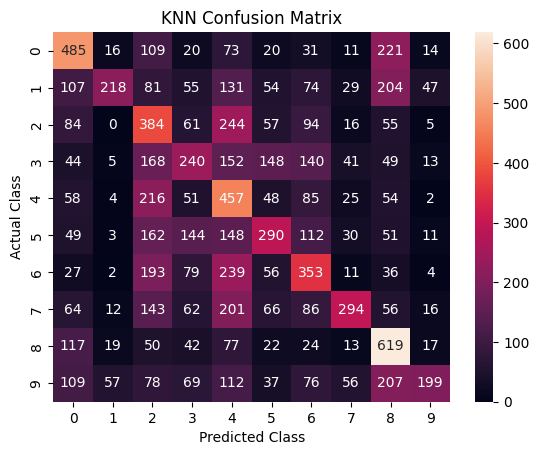

In [15]:
neighbors = np.argmax(accuracies_kNN) + 1
KNN = KNeighborsClassifier(n_neighbors=neighbors)
KNN.fit(X_train_df, y_train_flat)
y_pred_KNN = KNN.predict(X_test_df)
accuracy_kNN = accuracy_score(y_test_flat, y_pred_KNN)
classificationReport_KNN = classification_report(y_test_flat, y_pred_KNN)
f1_KNN = f1_score(y_test_flat, y_pred_KNN, average= "macro")
confusionMatrix_KNN = confusion_matrix(y_test_flat, y_pred_KNN)
print(f"all Number of neighbors had the same accuracy of {accuracy_kNN}")
print(f"Classification Report:\n{classificationReport_KNN}")
print(f"F1 Score: {f1_KNN}")
sns.heatmap(confusionMatrix_KNN, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

GaussianNB Accuracy: 0.2976
Classification Report:
              precision    recall  f1-score   support

           0       0.27      0.49      0.35      1000
           1       0.41      0.17      0.24      1000
           2       0.19      0.08      0.12      1000
           3       0.25      0.08      0.12      1000
           4       0.24      0.42      0.30      1000
           5       0.31      0.26      0.29      1000
           6       0.25      0.47      0.33      1000
           7       0.42      0.13      0.20      1000
           8       0.39      0.47      0.42      1000
           9       0.38      0.41      0.39      1000

    accuracy                           0.30     10000
   macro avg       0.31      0.30      0.28     10000
weighted avg       0.31      0.30      0.28     10000

F1 Score: 0.2754627838655197


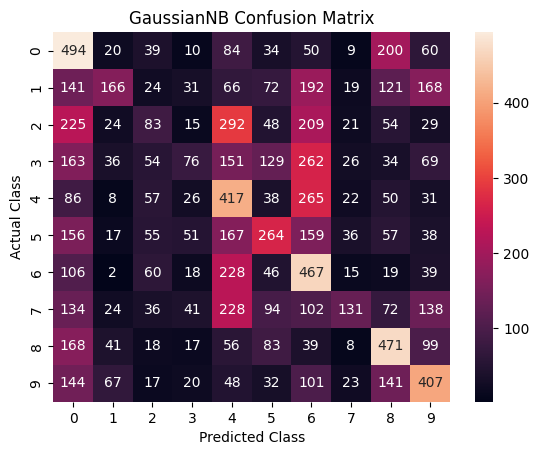

In [16]:
gaussianNB = GaussianNB()
gaussianNB.fit(X_train_df, y_train_flat)
y_pred_GNB = gaussianNB.predict(X_test_df)
accuracy_GNB = accuracy_score(y_test_flat, y_pred_GNB)
classificationReport_GNB = classification_report(y_test_flat, y_pred_GNB)
f1_GNB = f1_score(y_test_flat, y_pred_GNB, average= "macro")
confusionMatrix_GNB = confusion_matrix(y_test_flat, y_pred_GNB)
print(f"GaussianNB Accuracy: {accuracy_GNB}")
print(f"Classification Report:\n{classificationReport_GNB}")
print(f"F1 Score: {f1_GNB}")
sns.heatmap(confusionMatrix_GNB, annot=True, fmt='d')
plt.title("GaussianNB Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [17]:
from sklearn.decomposition import PCA

pca = PCA()

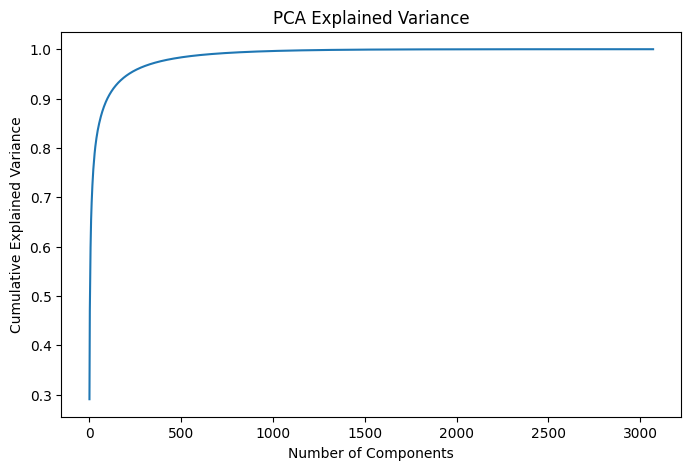

In [19]:
pca.fit(X_train_df)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [20]:
pca = PCA(n_components=100)

X_train_pca = pca.fit_transform(X_train_df)
X_test_pca = pca.transform(X_test_df)

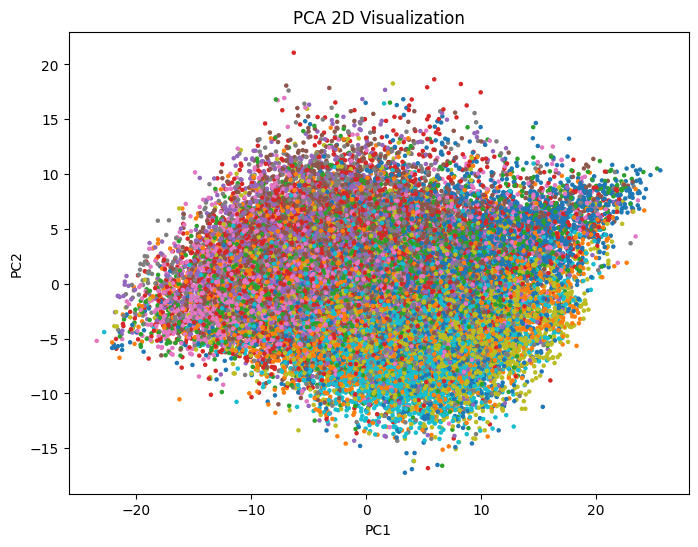

In [21]:
pca_2d = PCA(n_components=2)

X_train_2d = pca_2d.fit_transform(X_train_df)

plt.figure(figsize=(8,6))
plt.scatter(X_train_2d[:,0], X_train_2d[:,1], c=y_train_flat, cmap="tab10", s=5)
plt.title("PCA 2D Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

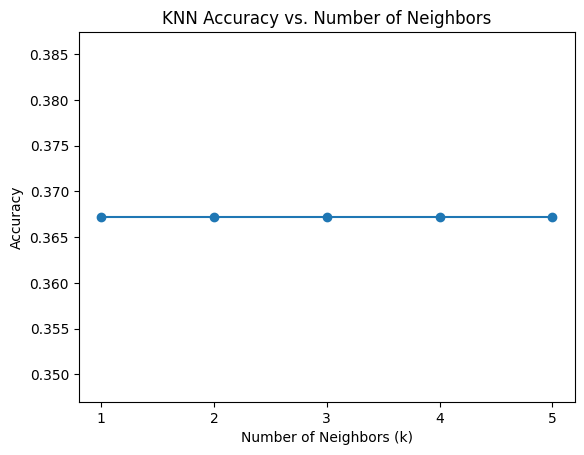

In [22]:

accuracies_kNN = []
for i in range(1, 6):
    KNN = KNeighborsClassifier(n_neighbors=3)
    KNN.fit(X_train_pca, y_train_flat)
    y_pred_KNN = KNN.predict(X_test_pca)
    accuracy_kNN = accuracy_score(y_test_flat, y_pred_KNN)
    accuracies_kNN.append(accuracy_kNN)
plt.plot(range(1, 6), accuracies_kNN, marker='o')
plt.xticks(range(1, 6))
plt.title("KNN Accuracy vs. Number of Neighbors")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.show()

all Number of neighbors had the same accuracy of 0.3854
Classification Report for KNN with PCA:
              precision    recall  f1-score   support

           0       0.44      0.51      0.47      1000
           1       0.59      0.31      0.41      1000
           2       0.27      0.40      0.32      1000
           3       0.31      0.24      0.27      1000
           4       0.28      0.43      0.34      1000
           5       0.39      0.30      0.34      1000
           6       0.34      0.46      0.39      1000
           7       0.54      0.36      0.43      1000
           8       0.45      0.58      0.50      1000
           9       0.58      0.27      0.37      1000

    accuracy                           0.39     10000
   macro avg       0.42      0.39      0.38     10000
weighted avg       0.42      0.39      0.38     10000

F1 Score: 0.3847058314737176


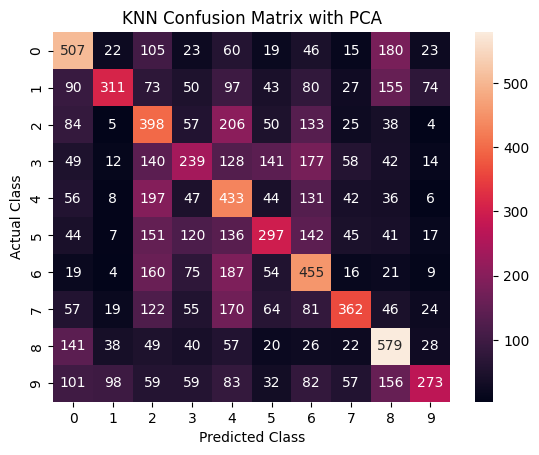

In [23]:
neighbors = np.argmax(accuracies_kNN) + 1
KNN = KNeighborsClassifier(n_neighbors=neighbors)
KNN.fit(X_train_pca, y_train_flat)
y_pred_KNN = KNN.predict(X_test_pca)
accuracy_kNN = accuracy_score(y_test_flat, y_pred_KNN)
classificationReport_KNN = classification_report(y_test_flat, y_pred_KNN)
f1_KNN = f1_score(y_test_flat, y_pred_KNN, average= "macro")
confusionMatrix_KNN = confusion_matrix(y_test_flat, y_pred_KNN)
print(f"all Number of neighbors had the same accuracy of {accuracy_kNN}")
print(f"Classification Report for KNN with PCA:\n{classificationReport_KNN}")
print(f"F1 Score: {f1_KNN}")
sns.heatmap(confusionMatrix_KNN, annot=True, fmt='d')
plt.title("KNN Confusion Matrix with PCA")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

GaussianNB Accuracy: 0.3375
Classification Report for GaussianNB with PCA:
              precision    recall  f1-score   support

           0       0.39      0.20      0.26      1000
           1       0.42      0.45      0.44      1000
           2       0.19      0.09      0.13      1000
           3       0.29      0.21      0.24      1000
           4       0.24      0.61      0.34      1000
           5       0.36      0.25      0.30      1000
           6       0.42      0.33      0.37      1000
           7       0.44      0.35      0.39      1000
           8       0.41      0.41      0.41      1000
           9       0.34      0.47      0.39      1000

    accuracy                           0.34     10000
   macro avg       0.35      0.34      0.33     10000
weighted avg       0.35      0.34      0.33     10000

F1 Score: 0.3273322123399184


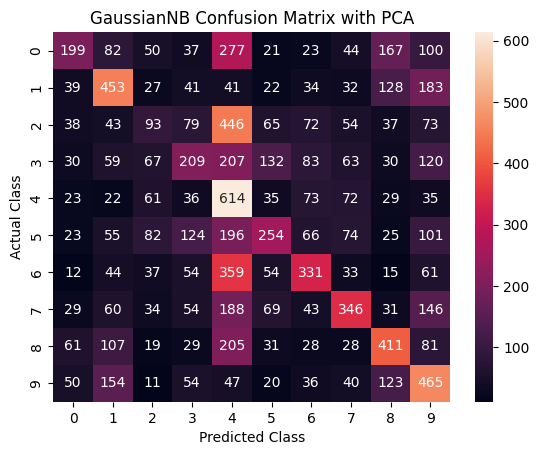

In [24]:
gaussianNB = GaussianNB()
gaussianNB.fit(X_train_pca, y_train_flat)
y_pred_GNB = gaussianNB.predict(X_test_pca)
accuracy_GNB = accuracy_score(y_test_flat, y_pred_GNB)
classificationReport_GNB = classification_report(y_test_flat, y_pred_GNB)
f1_GNB = f1_score(y_test_flat, y_pred_GNB, average= "macro")
confusionMatrix_GNB = confusion_matrix(y_test_flat, y_pred_GNB)
print(f"GaussianNB Accuracy: {accuracy_GNB}")
print(f"Classification Report for GaussianNB with PCA:\n{classificationReport_GNB}")
print(f"F1 Score: {f1_GNB}")
sns.heatmap(confusionMatrix_GNB, annot=True, fmt='d')
plt.title("GaussianNB Confusion Matrix with PCA")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()